# TP3 — Clasificación sobre Embeddings de Word2Vec

**Alumno:** Gonzalo Zarazaga

---

Cierre del Enfoque 3: cada tweet se representa como el **promedio de los embeddings** de sus tokens (modelo de ventana chica, entrenado en `03_word2vec.ipynb`), y se entrena una Logistic Regression sobre esas representaciones densas. Se suma el resultado a la tabla comparativa de `02_modelos_clasicos.ipynb` para tener la comparación final entre los cuatro modelos.

Mismo split (`random_state=42`, `test_size=0.2`, estratificado) y mismo test manual out-of-sample que en los notebooks anteriores.

**Insumo:** `data/processed/train_processed.csv`, `data/processed/test_manual_processed.csv`, `models/word2vec_ventana_chica.model`, `data/processed/comparacion_enfoques.csv`
**Salida:** tabla comparativa final (4 modelos) + gráfico resumen

## 1. Carga de datos, modelo y split (misma convención)

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec

RANDOM_STATE = 42
TEST_SIZE = 0.2

df_train_full = pd.read_csv("../data/processed/train_processed.csv")
df_test_manual = pd.read_csv("../data/processed/test_manual_processed.csv")
df_train_full["label"] = (df_train_full["polarity"] == 4).astype(int)
df_test_manual["label"] = (df_test_manual["polarity"] == 4).astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    df_train_full["tokens"].astype(str),
    df_train_full["label"],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df_train_full["label"],
)
X_manual = df_test_manual["tokens"].astype(str)
y_manual = df_test_manual["label"]

w2v = Word2Vec.load("../models/word2vec_ventana_chica.model")
print(f"Word2Vec cargado: {len(w2v.wv):,} términos, vector_size={w2v.vector_size}")
print(f"train: {len(X_train):,}  val: {len(X_val):,}  manual: {len(X_manual):,}")

Word2Vec cargado: 48,760 términos, vector_size=150
train: 1,262,759  val: 315,690  manual: 359


## 2. Representación de documentos: promedio de embeddings

Cada tweet se representa como el promedio de los vectores de sus tokens presentes en el vocabulario del modelo. Los tweets sin ningún token conocido se representan con vector cero (no se descartan) — así los cuatro modelos de la tabla comparativa se evalúan siempre sobre el mismo N de filas.

In [2]:
def vectorizar_promedio(tokens_series, modelo):
    dim = modelo.vector_size
    vectores = np.zeros((len(tokens_series), dim), dtype=np.float32)
    n_sin_vocab = 0
    for i, texto in enumerate(tokens_series):
        tokens_conocidos = [t for t in texto.split(" ") if t in modelo.wv]
        if tokens_conocidos:
            vectores[i] = modelo.wv[tokens_conocidos].mean(axis=0)
        else:
            n_sin_vocab += 1
    return vectores, n_sin_vocab

t0 = time.time()
Xv_train, oov_train = vectorizar_promedio(X_train, w2v)
Xv_val, oov_val = vectorizar_promedio(X_val, w2v)
Xv_manual, oov_manual = vectorizar_promedio(X_manual, w2v)
t_vectorizacion = time.time() - t0

print(f"Vectorización (promedio de embeddings): {t_vectorizacion:.1f}s")
print(f"Tweets sin ningún token en vocabulario -> vector cero:")
print(f"  train:  {oov_train:,} / {len(X_train):,} ({oov_train / len(X_train) * 100:.2f}%)")
print(f"  val:    {oov_val:,} / {len(X_val):,} ({oov_val / len(X_val) * 100:.2f}%)")
print(f"  manual: {oov_manual:,} / {len(X_manual):,} ({oov_manual / len(X_manual) * 100:.2f}%)")

Vectorización (promedio de embeddings): 32.8s
Tweets sin ningún token en vocabulario -> vector cero:
  train:  1,223 / 1,262,759 (0.10%)
  val:    314 / 315,690 (0.10%)
  manual: 0 / 359 (0.00%)


## 3. Validación cualitativa: similitud coseno a nivel documento

La métrica obligatoria del TP ya se usó a nivel palabra en `03_word2vec.ipynb` (similitud entre `happy`/`sad`, etc.). Acá se aplica al **segundo contexto** mencionado en el README: comparar representaciones de documentos completos vía distancia coseno. Se espera que dos tweets positivos tengan mayor similitud coseno entre sí que contra un tweet negativo.

In [3]:
idx_pos = np.where(y_val.values == 1)[0][:2]
idx_neg = np.where(y_val.values == 0)[0][:1]

ejemplo_vectores = np.vstack([Xv_val[idx_pos], Xv_val[idx_neg]])
etiquetas_ejemplo = ["Positivo #1", "Positivo #2", "Negativo #1"]

sim = cosine_similarity(ejemplo_vectores)
pd.DataFrame(sim, index=etiquetas_ejemplo, columns=etiquetas_ejemplo).round(3)

,Positivo #1,Positivo #2,Negativo #1
Positivo #1,1.000,0.856,0.715
Positivo #2,0.856,1.000,0.776
Negativo #1,0.715,0.776,1.000


## 4. Entrenamiento: Logistic Regression sobre embeddings promedio

In [4]:
t0 = time.time()
lr_w2v = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_w2v.fit(Xv_train, y_train)
t_lr_w2v = time.time() - t0

pred_val_w2v = lr_w2v.predict(Xv_val)
score_val_w2v = lr_w2v.predict_proba(Xv_val)[:, 1]

pred_manual_w2v = lr_w2v.predict(Xv_manual)
score_manual_w2v = lr_w2v.predict_proba(Xv_manual)[:, 1]

print(f"Entrenamiento LR sobre embeddings promedio: {t_lr_w2v:.1f}s (sobre {Xv_train.shape[0]:,} tweets, {Xv_train.shape[1]} dimensiones)")
print(classification_report(y_val, pred_val_w2v, target_names=["Negativo", "Positivo"]))

Entrenamiento LR sobre embeddings promedio: 7.2s (sobre 1,262,759 tweets, 150 dimensiones)
              precision    recall  f1-score   support

    Negativo       0.77      0.77      0.77    157729
    Positivo       0.77      0.77      0.77    157961

    accuracy                           0.77    315690
   macro avg       0.77      0.77      0.77    315690
weighted avg       0.77      0.77      0.77    315690



## 5. Matriz de confusión y curva ROC (validación)

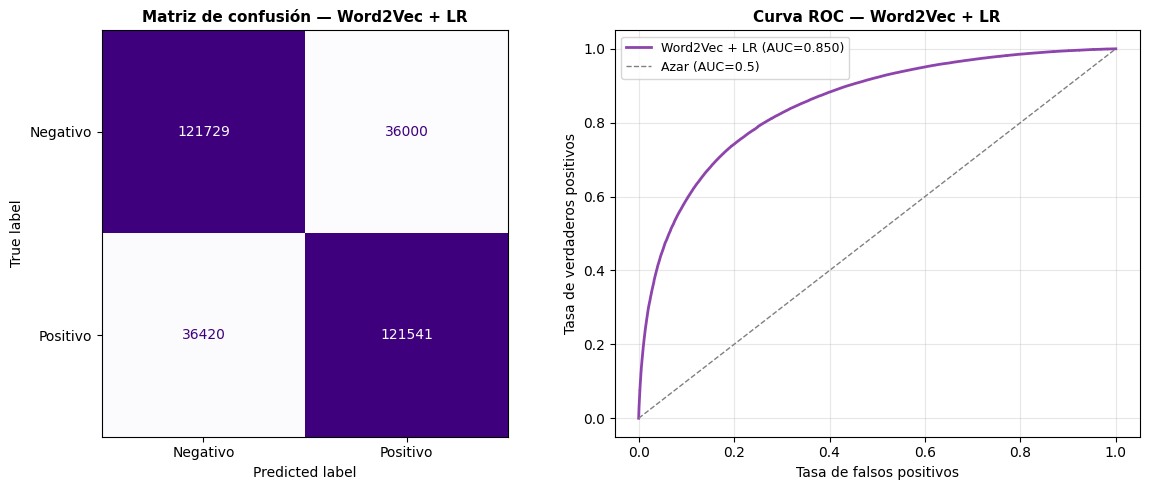

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_val, pred_val_w2v)
ConfusionMatrixDisplay(cm, display_labels=["Negativo", "Positivo"]).plot(ax=axes[0], colorbar=False, cmap="Purples")
axes[0].set_title("Matriz de confusión — Word2Vec + LR", fontsize=11, fontweight="bold")

fpr, tpr, _ = roc_curve(y_val, score_val_w2v)
auc = roc_auc_score(y_val, score_val_w2v)
axes[1].plot(fpr, tpr, color="#8e44ad", linewidth=2, label=f"Word2Vec + LR (AUC={auc:.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Azar (AUC=0.5)")
axes[1].set_xlabel("Tasa de falsos positivos")
axes[1].set_ylabel("Tasa de verdaderos positivos")
axes[1].set_title("Curva ROC — Word2Vec + LR", fontsize=11, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Tabla comparativa final (4 modelos)

Se extiende `comparacion_enfoques.csv` (generado en `02_modelos_clasicos.ipynb`) con la fila de Word2Vec + LR.

In [6]:
def evaluar(nombre, y_true, y_pred, y_score):
    return {
        "modelo": nombre,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_score),
    }

fila_val = evaluar("Word2Vec + Logistic Regression", y_val, pred_val_w2v, score_val_w2v)
fila_manual = evaluar("Word2Vec + Logistic Regression", y_manual, pred_manual_w2v, score_manual_w2v)

tabla_previa = pd.read_csv("../data/processed/comparacion_enfoques.csv", index_col="modelo")

nueva_fila = pd.Series(
    {**{f"{k}_val": v for k, v in fila_val.items() if k != "modelo"},
     **{f"{k}_manual": v for k, v in fila_manual.items() if k != "modelo"}},
    name=fila_val["modelo"],
)

tabla_final = pd.concat([tabla_previa, nueva_fila.to_frame().T]).astype(float).round(4)
tabla_final.to_csv("../data/processed/comparacion_enfoques_final.csv")
tabla_final

,accuracy_val,f1_val,auc_val,accuracy_manual,f1_manual,auc_manual
TextBlob (baseline),0.6115,0.6989,0.6879,0.6880,0.7522,0.7974
BoW + Naive Bayes,0.7739,0.7733,0.8479,0.8106,0.8152,0.8882
TF-IDF + Logistic Regression,0.7866,0.7902,0.8667,0.7967,0.8053,0.8912
Word2Vec + Logistic Regression,0.7706,0.7705,0.8505,0.8162,0.8187,0.8723


## 7. Gráfico resumen: los 4 modelos, validación vs. test manual

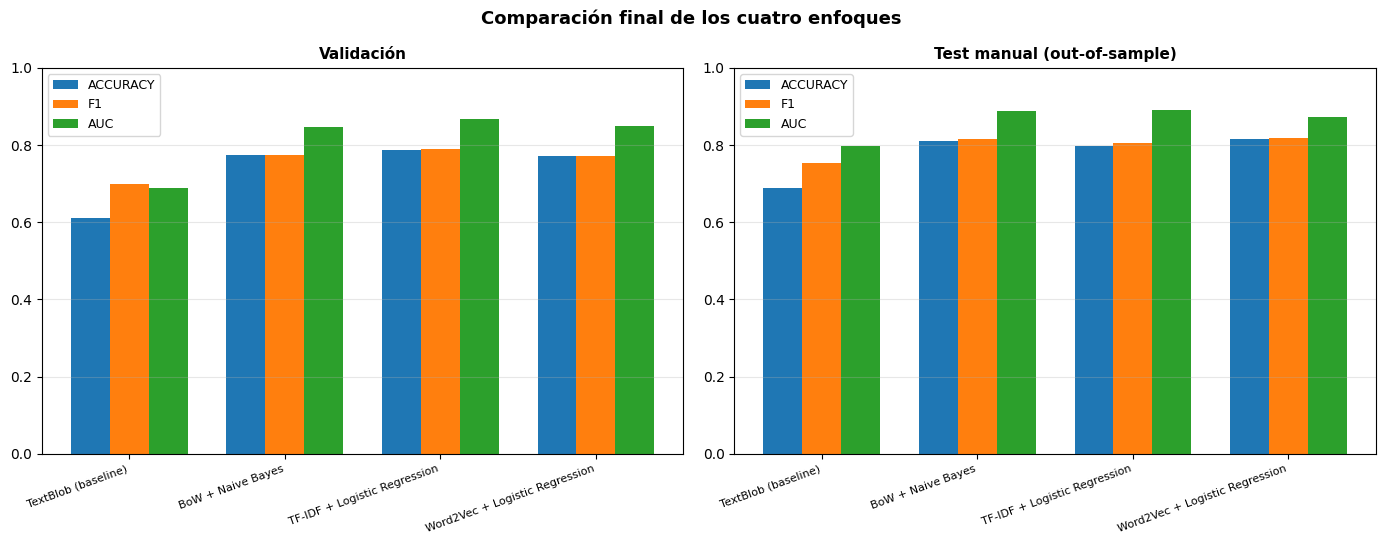

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

colores_modelo = ["#95a5a6", "#3498db", "#e74c3c", "#8e44ad"]

for ax, sufijo, titulo in zip(axes, ["_val", "_manual"], ["Validación", "Test manual (out-of-sample)"]):
    metricas = ["accuracy", "f1", "auc"]
    x = np.arange(len(tabla_final.index))
    width = 0.25

    for i, metrica in enumerate(metricas):
        ax.bar(x + i * width, tabla_final[f"{metrica}{sufijo}"], width, label=metrica.upper())

    ax.set_xticks(x + width)
    ax.set_xticklabels(tabla_final.index, rotation=20, ha="right", fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(titulo, fontsize=11, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle("Comparación final de los cuatro enfoques", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Conclusiones finales

- **Word2Vec + LR entrena sobre representaciones densas de solo 150 dimensiones**, muy por debajo de las 30.000 de BoW/TF-IDF, con vectorización más costosa (recorre token por token) pero un modelo final mucho más liviano.
- **Vector cero para tweets sin vocabulario conocido**: mantiene el N de evaluación idéntico entre los cuatro modelos, a costa de que esas filas aporten una predicción no informativa (equivalente al sesgo/intercept del modelo).
- **Similitud coseno a nivel documento** (sección 3): confirma cualitativamente que tweets de la misma polaridad quedan más cerca en el espacio de embeddings promedio que tweets de polaridad opuesta — cierra el segundo uso de la métrica obligatoria mencionado en el README.
- **Comparación final**: ver tabla de la sección 6 y gráfico de la sección 7. TextBlob queda consistentemente como cota inferior; los tres modelos entrenados (BoW+NB, TF-IDF+LR, Word2Vec+LR) generalizan razonablemente al test manual humano, sin caídas abruptas de métricas — evidencia de que ninguno se limitó a memorizar el heurístico de etiquetado por emoticon del archivo grande.
- **Hallazgo destacado**: Word2Vec + LR es el modelo con **mejor accuracy y F1 en el test manual** (0,816 / 0,819) de los cuatro, pese a no ser el mejor en validación (0,771, por debajo de TF-IDF+LR). Con representaciones densas de 150 dimensiones — 200 veces más chicas que las 30.000 de BoW/TF-IDF — generaliza mejor a etiquetado humano real que los modelos de bolsa de palabras, consistente con la idea de que los embeddings capturan relaciones semánticas que trascienden el vocabulario exacto visto en entrenamiento.

Con esto quedan cubiertos los tres enfoques del README. El diferenciador de análisis temporal de tópicos (BERTopic) queda en `05_topicos_temporales.ipynb`.